<a href="https://colab.research.google.com/github/minseonju/Marine/blob/main/model/lstm/LSTM_ae_m1m2_combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# [셀 1] Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# [셀 2] 라이브러리 import & 전역 설정
import os
import pickle
import random

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
    classification_report,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

config = {
    'batch_size'  : 256,
    'epochs'      : 300,
    'hidden_dim'  : 64,
    'lr'          : 0.0001,
    'weight_decay': 1e-5,
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")


사용 디바이스: cuda


In [4]:
# [셀 3] 데이터 로드 & 시퀀스 생성 (M1 + M2 합산)
import pandas as pd
import numpy as np

# 학습: raw_events.csv (정상 데이터만)
df_train = pd.read_csv('/content/drive/MyDrive/raw_events.csv')
df_train = df_train.sort_values('ts_ns').reset_index(drop=True)

# 테스트: M1 / M2
df_m1 = pd.read_csv('/content/drive/MyDrive/raw_sockshop_m1.csv')
df_m1 = df_m1.sort_values('ts_ns').reset_index(drop=True)

df_m2 = pd.read_csv('/content/drive/MyDrive/raw_sockshop_m2.csv')
df_m2 = df_m2.sort_values('ts_ns').reset_index(drop=True)

print(f"학습 데이터: {len(df_train):,}행")
print(f"M1 데이터:   {len(df_m1):,}행")
print(f"M2 데이터:   {len(df_m2):,}행")
print(f"M1+M2 합계:  {len(df_m1)+len(df_m2):,}행")

# 학습 + M1 + M2 syscall 합집합 기준 사전 생성
unique_syscalls = sorted(
    set(df_train['syscall'].unique()) |
    set(df_m1['syscall'].unique())    |
    set(df_m2['syscall'].unique())
)
syscall_to_idx = {s: i for i, s in enumerate(unique_syscalls)}
VOCAB_SIZE     = len(unique_syscalls)
print(f"\n고유 syscall 수 (합집합): {VOCAB_SIZE}개")

WINDOW_NS  = int(1e9)
SEQ_WINDOW = 3

# ── 학습 시퀀스 생성 ──
ts_min = df_train['ts_ns'].min()
df_train['window_id'] = ((df_train['ts_ns'] - ts_min) // WINDOW_NS).astype(int)

grouped = df_train.groupby('window_id')['syscall'].value_counts().unstack(fill_value=0)
grouped = grouped.reindex(columns=unique_syscalls, fill_value=0)

train_vectors = grouped.values.astype(np.float32)
train_vectors = train_vectors / (train_vectors.sum(axis=1, keepdims=True) + 1e-8)

train_seqs = [train_vectors[i:i + SEQ_WINDOW]
              for i in range(len(train_vectors) - SEQ_WINDOW + 1)]
random.seed(SEED)
train_seqs = random.sample(train_seqs, min(200_000, len(train_seqs)))
train_seqs = np.array(train_seqs)
print(f"\n학습 시퀀스: {len(train_seqs):,}개  shape: {train_seqs.shape}")

# ── 테스트 시퀀스 생성 함수 ──
# M1과 M2는 수집 시간이 다르므로 각각 window_id를 독립적으로 생성 후 합산
def make_test_sequences(df, unique_syscalls, window_ns, seq_window):
    df = df.copy()
    ts_min = df['ts_ns'].min()
    df['window_id'] = ((df['ts_ns'] - ts_min) // window_ns).astype(int)

    grouped = df.groupby('window_id')['syscall'].value_counts().unstack(fill_value=0)
    grouped = grouped.reindex(columns=unique_syscalls, fill_value=0)
    vectors = grouped.values.astype(np.float32)
    vectors = vectors / (vectors.sum(axis=1, keepdims=True) + 1e-8)

    label_per_window = df.groupby('window_id')['label'].max()
    labels = label_per_window.values

    normal_seqs, attack_seqs = [], []
    for i in range(len(vectors) - seq_window + 1):
        seq   = vectors[i:i + seq_window]
        label = int(labels[i:i + seq_window].max())
        if label == 0:
            normal_seqs.append(seq)
        elif label == 1:
            attack_seqs.append(seq)
    return np.array(normal_seqs), np.array(attack_seqs)

m1_normal, m1_attack = make_test_sequences(df_m1, unique_syscalls, WINDOW_NS, SEQ_WINDOW)
m2_normal, m2_attack = make_test_sequences(df_m2, unique_syscalls, WINDOW_NS, SEQ_WINDOW)

print(f"M1 — 정상: {len(m1_normal):,}개  공격: {len(m1_attack):,}개")
print(f"M2 — 정상: {len(m2_normal):,}개  공격: {len(m2_attack):,}개")

# ── M1 + M2 합산 ──
test_normal_seqs = np.concatenate([m1_normal, m2_normal], axis=0)
test_attack_seqs = np.concatenate([m1_attack, m2_attack], axis=0)

print(f"\n[M1+M2 합산]")
print(f"정상: {len(test_normal_seqs):,}개  공격: {len(test_attack_seqs):,}개")


학습 데이터: 3,701,070행
M1 데이터:   6,808행
M2 데이터:   1,170,617행
M1+M2 합계:  1,177,425행

고유 syscall 수 (합집합): 108개

학습 시퀀스: 45,087개  shape: (45087, 3, 108)
M1 — 정상: 8개  공격: 15개
M2 — 정상: 62개  공격: 121개

[M1+M2 합산]
정상: 70개  공격: 136개


In [5]:
# [셀 4] numpy 배열을 PyTorch 텐서로 변환
X_train       = torch.tensor(train_seqs,       dtype=torch.float32).to(device)
X_normal_test = torch.tensor(test_normal_seqs, dtype=torch.float32).to(device)
X_attack      = torch.tensor(test_attack_seqs, dtype=torch.float32).to(device)

print(f"학습:    {X_train.shape}")
print(f"정상:    {X_normal_test.shape}")
print(f"공격:    {X_attack.shape}")


학습:    torch.Size([45087, 3, 108])
정상:    torch.Size([70, 3, 108])
공격:    torch.Size([136, 3, 108])


In [6]:
# [셀 5] LSTM-AE 모델 정의 & 학습
from torch.utils.data import DataLoader, TensorDataset

class LSTM_AE(nn.Module):
    def __init__(
        self,
        seq_len   : int = SEQ_WINDOW,
        input_dim : int = VOCAB_SIZE,
        hidden_dim: int = config['hidden_dim'],
    ) -> None:
        super().__init__()
        self.seq_len  = seq_len
        self.encoder  = nn.LSTM(
            input_dim, hidden_dim,
            num_layers=3, batch_first=True, dropout=0.2,
        )
        self.decoder  = nn.LSTM(
            hidden_dim, input_dim,
            num_layers=3, batch_first=True, dropout=0.2,
        )
        self.dropout  = nn.Dropout(0.2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        enc_out, (h, c) = self.encoder(x)
        dec_input       = torch.flip(enc_out, dims=[1])
        dec_out, _      = self.decoder(dec_input)
        dec_out         = self.dropout(dec_out)
        return dec_out

model     = LSTM_AE().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

loader = DataLoader(TensorDataset(X_train), batch_size=config['batch_size'], shuffle=True)

train_losses: list[float] = []
best_loss    = float('inf')
patience_cnt = 0
PATIENCE     = 20
os.makedirs('model', exist_ok=True)

print("학습 시작...")
for epoch in range(config['epochs']):
    model.train()
    total_loss = 0.0
    for (batch,) in loader:
        optimizer.zero_grad()
        output = model(batch)
        loss   = criterion(output, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)

    if avg_loss < best_loss:
        best_loss    = avg_loss
        patience_cnt = 0
        torch.save(model.state_dict(), 'model/best_lstm_ae.pth')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early Stopping at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f} | Patience: {patience_cnt}/{PATIENCE}")

print(f"학습 완료! Best Loss: {best_loss:.6f}")


학습 시작...
Epoch   0 | Loss: 0.002195 | LR: 0.000100 | Patience: 0/20
Epoch  10 | Loss: 0.001283 | LR: 0.000100 | Patience: 0/20
Epoch  20 | Loss: 0.001277 | LR: 0.000100 | Patience: 2/20
Epoch  30 | Loss: 0.001273 | LR: 0.000100 | Patience: 4/20
Epoch  40 | Loss: 0.001267 | LR: 0.000100 | Patience: 0/20
Epoch  50 | Loss: 0.001264 | LR: 0.000100 | Patience: 0/20
Epoch  60 | Loss: 0.001266 | LR: 0.000100 | Patience: 10/20
Epoch  70 | Loss: 0.001265 | LR: 0.000050 | Patience: 2/20
Epoch  80 | Loss: 0.001264 | LR: 0.000025 | Patience: 12/20
Early Stopping at epoch 88
학습 완료! Best Loss: 0.001264


In [7]:
# [셀 6] 복원 오차 계산 & 성능 평가 (M1+M2 합산)
def compute_reconstruction_errors(model, X, batch_sz):
    model.eval()
    errors = []
    with torch.no_grad():
        for i in range(0, len(X), batch_sz):
            batch  = X[i:i + batch_sz]
            output = model(batch)
            err    = torch.mean((output - batch) ** 2, dim=(1, 2))
            errors.extend(err.cpu().numpy())
    return np.array(errors)

BATCH_SIZE    = config['batch_size']
normal_errors = compute_reconstruction_errors(model, X_normal_test, BATCH_SIZE)
attack_errors = compute_reconstruction_errors(model, X_attack,      BATCH_SIZE)

print(f"정상 오차 — mean: {normal_errors.mean():.6f}, std: {normal_errors.std():.6f}")
print(f"공격 오차 — mean: {attack_errors.mean():.6f}, std: {attack_errors.std():.6f}")
print(f"오차 차이 (공격-정상): {attack_errors.mean() - normal_errors.mean():.6f}")

all_errors = np.concatenate([normal_errors, attack_errors])
y_true     = np.array([0] * len(normal_errors) + [1] * len(attack_errors))
pct_range  = np.arange(50, 99, 0.5)

best_f1, best_t = 0.0, 0.0
for pct in pct_range:
    t    = np.percentile(normal_errors, pct)
    pred = (all_errors > t).astype(int)
    f1   = f1_score(y_true, pred, average='macro', zero_division=0)
    if f1 > best_f1:
        best_f1, best_t = f1, t

threshold = best_t
y_pred    = (all_errors > threshold).astype(int)

fpr_arr, tpr_arr, _ = roc_curve(y_true, all_errors)
tn, fp, fn, tp      = confusion_matrix(y_true, y_pred).ravel()

print(f"\n=== 임계값 ===")
print(f"최적 임계값: {threshold:.6f}  (macro F1: {best_f1:.4f})")
print(f"TP: {tp}  TN: {tn}  FP: {fp}  FN: {fn}")
print(f"Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}")
print(f"F1-Score  : {f1_score(y_true, y_pred, zero_division=0):.4f}")
print(f"Macro F1  : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_true, all_errors):.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Attack'], zero_division=0))


정상 오차 — mean: 0.001590, std: 0.000384
공격 오차 — mean: 0.001594, std: 0.000424
오차 차이 (공격-정상): 0.000004

=== 임계값 ===
최적 임계값: 0.001743  (macro F1: 0.8137)
TP: 104  TN: 65  FP: 5  FN: 32
Precision : 0.9541
Recall    : 0.7647
F1-Score  : 0.8490
Macro F1  : 0.8137
AUC-ROC   : 0.7520

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.67      0.93      0.78        70
      Attack       0.95      0.76      0.85       136

    accuracy                           0.82       206
   macro avg       0.81      0.85      0.81       206
weighted avg       0.86      0.82      0.83       206



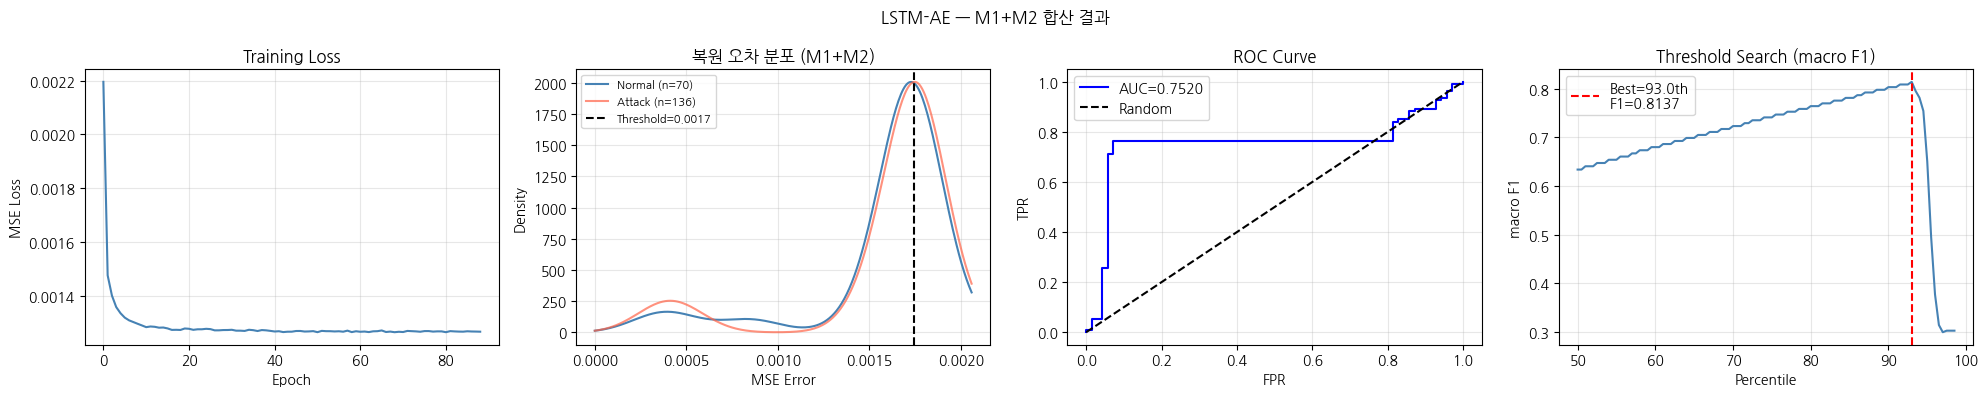

저장 완료: lstm_m1m2_combined.png


In [8]:
# [셀 7] 결과 시각화
from scipy.stats import gaussian_kde

!apt-get install -y fonts-nanum -qq
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family']        = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

x_range = np.linspace(0, max(normal_errors.max(), attack_errors.max()), 300)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('LSTM-AE — M1+M2 합산 결과')

axes[0].plot(train_losses, color='steelblue')
axes[0].set(title='Training Loss', xlabel='Epoch', ylabel='MSE Loss')
axes[0].grid(True, alpha=0.3)

kde_normal = gaussian_kde(normal_errors)
kde_attack = gaussian_kde(attack_errors)
axes[1].plot(x_range, kde_normal(x_range), color='steelblue', label=f'Normal (n={len(normal_errors)})')
axes[1].plot(x_range, kde_attack(x_range), color='tomato',    label=f'Attack (n={len(attack_errors)})', alpha=0.7)
axes[1].axvline(threshold, color='black', linestyle='--', label=f'Threshold={threshold:.4f}')
axes[1].set(title='복원 오차 분포 (M1+M2)', xlabel='MSE Error', ylabel='Density')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

axes[2].plot(fpr_arr, tpr_arr, color='blue', label=f'AUC={roc_auc_score(y_true, all_errors):.4f}')
axes[2].plot([0, 1], [0, 1], 'k--', label='Random')
axes[2].set(title='ROC Curve', xlabel='FPR', ylabel='TPR')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

f1_list = []
for pct in pct_range:
    t    = np.percentile(normal_errors, pct)
    pred = (all_errors > t).astype(int)
    f1_list.append(f1_score(y_true, pred, average='macro', zero_division=0))
best_pct = pct_range[int(np.argmax(f1_list))]
axes[3].plot(pct_range, f1_list, color='steelblue')
axes[3].axvline(best_pct, color='red', linestyle='--', label=f'Best={best_pct:.1f}th\nF1={max(f1_list):.4f}')
axes[3].set(title='Threshold Search (macro F1)', xlabel='Percentile', ylabel='macro F1')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_m1m2_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: lstm_m1m2_combined.png")


In [ ]:
# [셀 8] 모델 저장
os.makedirs('model', exist_ok=True)

with open('model/syscall_to_idx.pkl', 'wb') as f:
    pickle.dump(syscall_to_idx, f)
np.save('model/threshold.npy', threshold)

DRIVE_OUT = '/content/drive/MyDrive'
torch.save(model.state_dict(), f'{DRIVE_OUT}/best_lstm_ae.pth')
np.save(f'{DRIVE_OUT}/m1m2_normal_errors.npy', normal_errors)
np.save(f'{DRIVE_OUT}/m1m2_attack_errors.npy', attack_errors)
np.save(f'{DRIVE_OUT}/m1m2_threshold.npy',     threshold)

print("저장 완료")


저장 완료


In [ ]:
# [셀 9] 모델 파일 다운로드
from google.colab import files

files.download('model/best_lstm_ae.pth')
files.download('model/syscall_to_idx.pkl')
files.download('model/threshold.npy')

print("다운로드 완료!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

다운로드 완료!
